In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Step 2: Load the Dataset
print("📂 Loading MegaGymDataset...")
df = pd.read_csv('megaGymDataset (1).csv')
print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

📂 Loading MegaGymDataset...
✅ Dataset loaded successfully!
📊 Shape: (2918, 9)
📋 Columns: ['Unnamed: 0', 'Title', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating', 'RatingDesc']


In [4]:
# Step 3: Initial Data Exploration
print("\n🔍 Initial Data Exploration:")
print("=" * 50)

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Data types
print("\n📝 Data Types:")
print(df.dtypes)

# Check for missing values
print("\n❓ Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Basic statistics
print("\n📈 Basic Statistics:")
print(df.describe())


🔍 Initial Data Exploration:

First 5 rows:
   Unnamed: 0                         Title  \
0           0        Partner plank band row   
1           1  Banded crunch isometric hold   
2           2         FYR Banded Plank Jack   
3           3                 Banded crunch   
4           4                        Crunch   

                                                Desc      Type    BodyPart  \
0  The partner plank band row is an abdominal exe...  Strength  Abdominals   
1  The banded crunch isometric hold is an exercis...  Strength  Abdominals   
2  The banded plank jack is a variation on the pl...  Strength  Abdominals   
3  The banded crunch is an exercise targeting the...  Strength  Abdominals   
4  The crunch is a popular core exercise targetin...  Strength  Abdominals   

  Equipment         Level  Rating RatingDesc  
0     Bands  Intermediate     0.0        NaN  
1     Bands  Intermediate     NaN        NaN  
2     Bands  Intermediate     NaN        NaN  
3     Bands  Int

In [5]:
# Step 4: Data Cleaning
print("\n🧹 Data Cleaning...")

# Fill missing values
df_clean = df.copy()

# Handle missing values
if 'Rating' in df_clean.columns and df_clean['Rating'].isnull().sum() > 0:
    df_clean['Rating'].fillna(df_clean['Rating'].median(), inplace=True)

if 'RatingDescription' in df_clean.columns and df_clean['RatingDescription'].isnull().sum() > 0:
    df_clean['RatingDescription'].fillna('Not Rated', inplace=True)

if 'BodyPart' in df_clean.columns and df_clean['BodyPart'].isnull().sum() > 0:
    df_clean['BodyPart'].fillna('Unknown', inplace=True)

# Create new features
def create_features(df):
    """Create new features for ML modeling"""
    
    # 1. Difficulty score (simplified)
    if 'Level' in df.columns:
        difficulty_map = {'Beginner': 1, 'Intermediate': 2, 'Expert': 3}
        df['Difficulty_Score'] = df['Level'].map(lambda x: difficulty_map.get(x, 2))
    
    # 2. Exercise category based on equipment
    if 'Equipment' in df.columns:
        df['Category'] = df['Equipment'].apply(
            lambda x: 'Bodyweight' if 'Body Only' in str(x) else 
                     'Gym Equipment' if pd.notnull(x) else 
                     'Other'
        )
    
    # 3. Popularity score (based on rating and rating count)
    if 'Rating' in df.columns:
        df['Popularity_Score'] = df['Rating'] * 20  # Scale rating
    
    # 4. Muscle group aggregation
    if 'BodyPart' in df.columns:
        muscle_groups = {
            'Abdominals': 'Core',
            'Abductors': 'Legs',
            'Adductors': 'Legs',
            'Biceps': 'Arms',
            'Calves': 'Legs',
            'Chest': 'Upper Body',
            'Forearms': 'Arms',
            'Glutes': 'Legs',
            'Hamstrings': 'Legs',
            'Lats': 'Back',
            'Lower Back': 'Back',
            'Middle Back': 'Back',
            'Neck': 'Other',
            'Quadriceps': 'Legs',
            'Shoulders': 'Upper Body',
            'Traps': 'Back',
            'Triceps': 'Arms'
        }
        df['Muscle_Group'] = df['BodyPart'].map(muscle_groups).fillna('Other')
    
    return df

df_clean = create_features(df_clean)
print("✅ Features created successfully!")


🧹 Data Cleaning...
✅ Features created successfully!



📊 Exploratory Data Analysis (EDA):


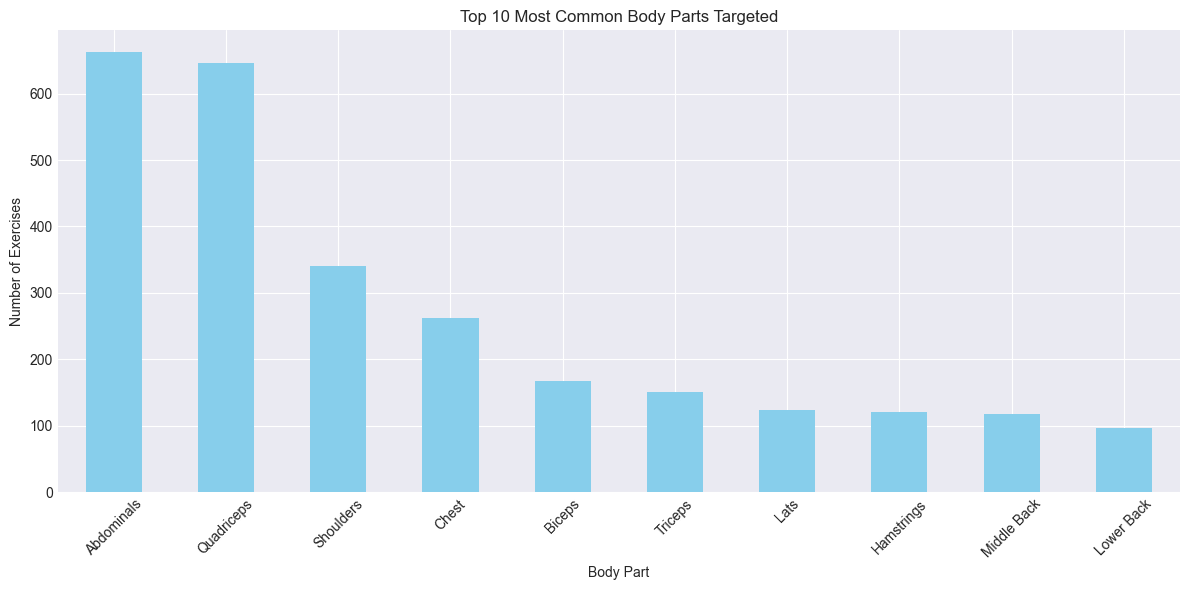

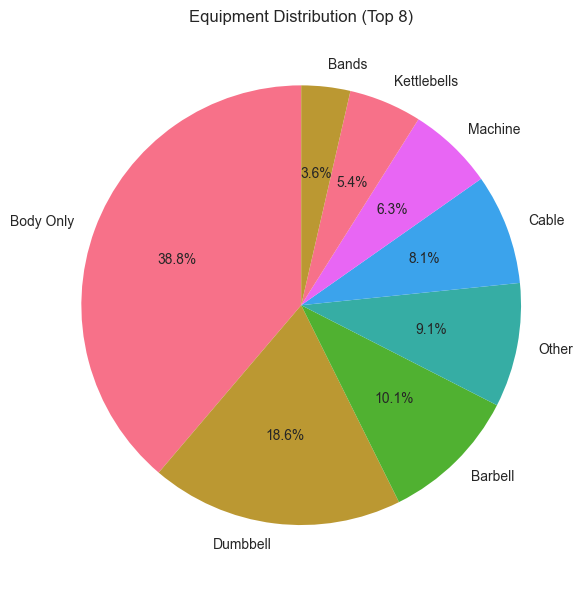

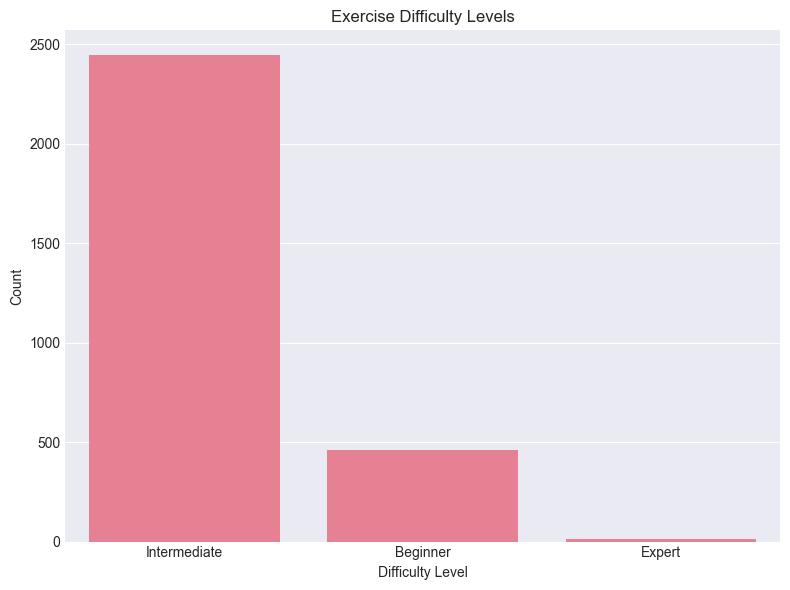

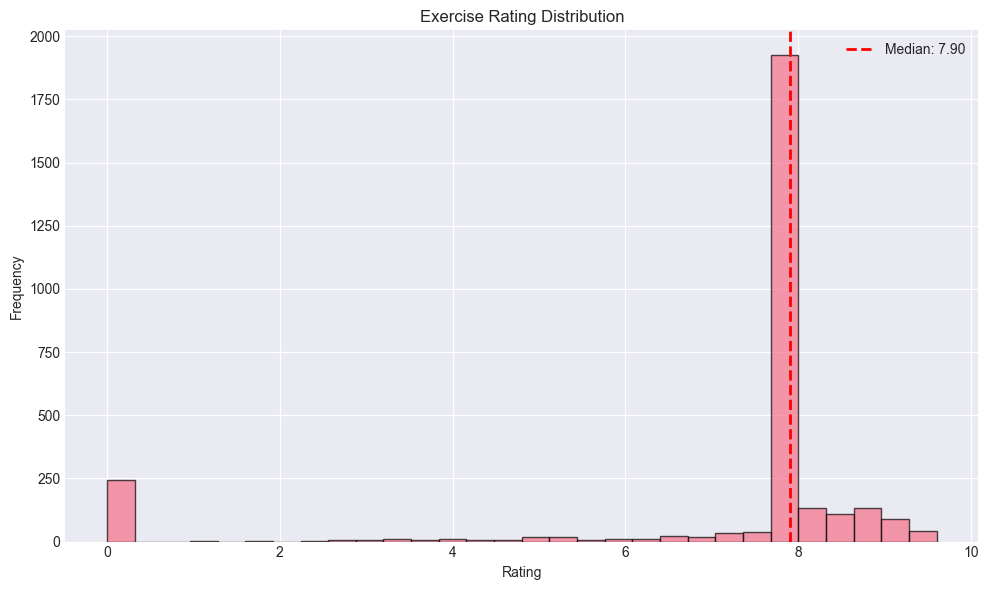

In [6]:
# Step 5: Exploratory Data Analysis (EDA)
print("\n📊 Exploratory Data Analysis (EDA):")

# 5.1: Exercise distribution by body part
if 'BodyPart' in df_clean.columns:
    plt.figure(figsize=(12, 6))
    body_part_counts = df_clean['BodyPart'].value_counts().head(10)
    body_part_counts.plot(kind='bar', color='skyblue')
    plt.title('Top 10 Most Common Body Parts Targeted')
    plt.xlabel('Body Part')
    plt.ylabel('Number of Exercises')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5.2: Equipment distribution
if 'Equipment' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    equipment_counts = df_clean['Equipment'].value_counts().head(8)
    equipment_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title('Equipment Distribution (Top 8)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# 5.3: Difficulty level distribution
if 'Level' in df_clean.columns:
    plt.figure(figsize=(8, 6))
    level_counts = df_clean['Level'].value_counts()
    sns.barplot(x=level_counts.index, y=level_counts.values)
    plt.title('Exercise Difficulty Levels')
    plt.xlabel('Difficulty Level')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# 5.4: Rating distribution
if 'Rating' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_clean['Rating'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    plt.title('Exercise Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.axvline(df_clean['Rating'].median(), color='red', linestyle='dashed', linewidth=2, label=f'Median: {df_clean["Rating"].median():.2f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
# Step 6: Prepare Data for Machine Learning
print("\n🤖 Preparing Data for Machine Learning...")

# Select relevant columns for ML
ml_columns = []
if 'BodyPart' in df_clean.columns:
    ml_columns.append('BodyPart')
if 'Equipment' in df_clean.columns:
    ml_columns.append('Equipment')
if 'Level' in df_clean.columns:
    ml_columns.append('Level')
if 'Rating' in df_clean.columns:
    ml_columns.append('Rating')
if 'Muscle_Group' in df_clean.columns:
    ml_columns.append('Muscle_Group')
if 'Category' in df_clean.columns:
    ml_columns.append('Category')
if 'Difficulty_Score' in df_clean.columns:
    ml_columns.append('Difficulty_Score')

# Create ML dataframe
ml_df = df_clean[ml_columns].copy()

# Encode categorical variables
label_encoders = {}
for col in ['BodyPart', 'Equipment', 'Level', 'Muscle_Group', 'Category']:
    if col in ml_df.columns:
        le = LabelEncoder()
        ml_df[col + '_encoded'] = le.fit_transform(ml_df[col].astype(str))
        label_encoders[col] = le

print(f"✅ ML Data shape: {ml_df.shape}")
print(f"📋 ML Columns: {ml_df.columns.tolist()}")


🤖 Preparing Data for Machine Learning...
✅ ML Data shape: (2918, 12)
📋 ML Columns: ['BodyPart', 'Equipment', 'Level', 'Rating', 'Muscle_Group', 'Category', 'Difficulty_Score', 'BodyPart_encoded', 'Equipment_encoded', 'Level_encoded', 'Muscle_Group_encoded', 'Category_encoded']


In [8]:
# Step 7: Build Recommendation Models
print("\n🎯 Building Recommendation Models...")

# 7.1: Exercise Popularity Model (Predict Rating)
if 'Rating' in ml_df.columns:
    # Prepare features and target
    feature_cols = [col for col in ml_df.columns if 'encoded' in col or 'Difficulty_Score' in col]
    X = ml_df[feature_cols]
    y = ml_df['Rating']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train model
    popularity_model = RandomForestRegressor(n_estimators=100, random_state=42)
    popularity_model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = popularity_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"📊 Popularity Model Performance:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   R² Score: {popularity_model.score(X_test, y_test):.4f}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': popularity_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n🔝 Top 5 Important Features:")
    print(feature_importance.head())

# %% [code]
# 7.2: Exercise Difficulty Classifier
if 'Level' in df_clean.columns:
    # Prepare data
    X_diff = ml_df[feature_cols]
    y_diff = ml_df['Level']
    
    # Encode target
    le_diff = LabelEncoder()
    y_diff_encoded = le_diff.fit_transform(y_diff)
    
    # Split
    X_train_diff, X_test_diff, y_train_diff, y_test_diff = train_test_split(
        X_diff, y_diff_encoded, test_size=0.2, random_state=42
    )
    
    # Train classifier
    difficulty_model = RandomForestClassifier(n_estimators=100, random_state=42)
    difficulty_model.fit(X_train_diff, y_train_diff)
    
    # Evaluate
    y_pred_diff = difficulty_model.predict(X_test_diff)
    accuracy = accuracy_score(y_test_diff, y_pred_diff)
    
    print(f"\n📈 Difficulty Classifier Performance:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test_diff, y_pred_diff, target_names=le_diff.classes_))

# %% [code]
# 7.3: Create Exercise Similarity Matrix
print("\n🔗 Creating Exercise Similarity Matrix...")

# Select key features for similarity
similarity_features = ['BodyPart', 'Equipment', 'Level', 'Muscle_Group']
similarity_df = df_clean[similarity_features].copy()

# One-hot encode for similarity
similarity_encoded = pd.get_dummies(similarity_df)

# Calculate cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(similarity_encoded)
similarity_df_matrix = pd.DataFrame(
    similarity_matrix,
    index=df_clean['Title'] if 'Title' in df_clean.columns else range(len(df_clean)),
    columns=df_clean['Title'] if 'Title' in df_clean.columns else range(len(df_clean))
)

print(f"✅ Similarity matrix shape: {similarity_matrix.shape}")

# Example: Get similar exercises for first exercise
if 'Title' in df_clean.columns:
    first_exercise = df_clean['Title'].iloc[0]
    similar_exercises = similarity_df_matrix[first_exercise].sort_values(ascending=False).head(6)
    print(f"\n🎯 Exercises similar to '{first_exercise}':")
    for idx, (exercise, score) in enumerate(similar_exercises.items()):
        if idx > 0:  # Skip the first one (itself)
            print(f"   {idx}. {exercise} (similarity: {score:.3f})")


🎯 Building Recommendation Models...
📊 Popularity Model Performance:
   RMSE: 2.0462
   R² Score: 0.2134

🔝 Top 5 Important Features:
                feature  importance
2     Equipment_encoded    0.238469
1      BodyPart_encoded    0.235957
3         Level_encoded    0.181803
0      Difficulty_Score    0.157442
4  Muscle_Group_encoded    0.130758

📈 Difficulty Classifier Performance:
   Accuracy: 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

    Beginner       1.00      1.00      1.00        95
      Expert       1.00      1.00      1.00         3
Intermediate       1.00      1.00      1.00       486

    accuracy                           1.00       584
   macro avg       1.00      1.00      1.00       584
weighted avg       1.00      1.00      1.00       584


🔗 Creating Exercise Similarity Matrix...
✅ Similarity matrix shape: (2918, 2918)

🎯 Exercises similar to 'Partner plank band row':
   1. Partner plank band row (similarity: 1.000)
   2

In [9]:
# Step 8: Create Workout Templates
print("\n💪 Creating Workout Templates...")

def create_workout_templates(df, muscle_group='All', difficulty='Intermediate', duration=30):
    """Generate workout templates based on parameters"""
    
    templates = {}
    
    # Filter exercises based on parameters
    filtered_df = df.copy()
    
    if muscle_group != 'All' and 'Muscle_Group' in df.columns:
        filtered_df = filtered_df[filtered_df['Muscle_Group'] == muscle_group]
    
    if difficulty != 'All' and 'Level' in df.columns:
        filtered_df = filtered_df[filtered_df['Level'] == difficulty]
    
    # Create different template types
    template_types = {
        'full_body': ['Upper Body', 'Lower Body', 'Core'],
        'upper_body': ['Upper Body', 'Arms', 'Back', 'Chest'],
        'lower_body': ['Legs', 'Glutes'],
        'core': ['Core'],
        'cardio': ['Full Body']
    }
    
    for template_name, target_groups in template_types.items():
        if 'Muscle_Group' in filtered_df.columns:
            template_exercises = filtered_df[filtered_df['Muscle_Group'].isin(target_groups)]
            
            if len(template_exercises) > 0:
                # Select 4-6 exercises for the template
                selected_exercises = template_exercises.sample(min(6, len(template_exercises)), random_state=42)
                
                templates[template_name] = {
                    'name': f"{template_name.replace('_', ' ').title()} Workout",
                    'duration': duration,
                    'difficulty': difficulty,
                    'exercises': selected_exercises[['Title', 'BodyPart', 'Equipment', 'Level']].to_dict('records')
                        if 'Title' in selected_exercises.columns else 
                        selected_exercises[['BodyPart', 'Equipment', 'Level']].to_dict('records'),
                    'estimated_calories': duration * 8,  # Rough estimate
                    'muscle_groups': target_groups
                }
    
    return templates

# Generate templates
workout_templates = create_workout_templates(df_clean)
print(f"✅ Created {len(workout_templates)} workout templates")

# Display sample template
if len(workout_templates) > 0:
    sample_template = list(workout_templates.values())[0]
    print(f"\n📋 Sample Template: {sample_template['name']}")
    print(f"   Duration: {sample_template['duration']} minutes")
    print(f"   Difficulty: {sample_template['difficulty']}")
    print(f"   Exercises: {len(sample_template['exercises'])}")


💪 Creating Workout Templates...
✅ Created 4 workout templates

📋 Sample Template: Full Body Workout
   Duration: 30 minutes
   Difficulty: Intermediate
   Exercises: 6


In [10]:
# Step 9: Export Trained Models and Data for React App
print("\n📤 Exporting Data for React Application...")

# 9.1: Create comprehensive data structure
export_data = {
    "metadata": {
        "export_date": datetime.now().isoformat(),
        "dataset_name": "MegaGymDataset",
        "total_exercises": len(df_clean),
        "model_version": "1.0.0"
    },
    
    "exercise_database": df_clean.head(100).to_dict('records'),  # Export top 100 exercises
    
    "statistics": {
        "total_exercises": len(df_clean),
        "unique_body_parts": df_clean['BodyPart'].nunique() if 'BodyPart' in df_clean.columns else 0,
        "unique_equipment": df_clean['Equipment'].nunique() if 'Equipment' in df_clean.columns else 0,
        "average_rating": float(df_clean['Rating'].mean()) if 'Rating' in df_clean.columns else 0,
        "difficulty_distribution": df_clean['Level'].value_counts().to_dict() if 'Level' in df_clean.columns else {}
    },
    
    "ml_models": {
        "popularity_model": {
            "feature_importance": feature_importance.head(10).to_dict('records') if 'feature_importance' in locals() else [],
            "rmse": float(rmse) if 'rmse' in locals() else 0,
            "sample_predictions": []
        },
        
        "difficulty_model": {
            "accuracy": float(accuracy) if 'accuracy' in locals() else 0,
            "classes": le_diff.classes_.tolist() if 'le_diff' in locals() else []
        }
    },
    
    "workout_templates": workout_templates,
    
    "exercise_categories": {
        "by_body_part": df_clean['BodyPart'].value_counts().head(20).to_dict() if 'BodyPart' in df_clean.columns else {},
        "by_equipment": df_clean['Equipment'].value_counts().head(15).to_dict() if 'Equipment' in df_clean.columns else {},
        "by_difficulty": df_clean['Level'].value_counts().to_dict() if 'Level' in df_clean.columns else {}
    },
    
    "recommendation_rules": {
        "beginner_routines": [
            {"exercises": ["Bodyweight Squats", "Knee Push-ups", "Plank"], "sets": 3, "reps": "10-12"},
            {"exercises": ["Lunges", "Wall Push-ups", "Bird Dog"], "sets": 3, "reps": "8-10"}
        ],
        "intermediate_routines": [
            {"exercises": ["Push-ups", "Squats", "Lunges", "Plank"], "sets": 4, "reps": "12-15"},
            {"exercises": ["Burpees", "Mountain Climbers", "Jumping Jacks"], "sets": 4, "reps": "15-20"}
        ]
    }
}

# 9.2: Add sample predictions
if 'popularity_model' in locals():
    sample_indices = X_test.sample(min(5, len(X_test)), random_state=42).index
    sample_predictions = []
    
    for idx in sample_indices:
        if idx < len(df_clean):
            exercise_data = df_clean.iloc[idx]
            prediction = popularity_model.predict([X_test.loc[idx]])[0] if idx in X_test.index else 0
            
            sample_predictions.append({
                "exercise_name": exercise_data.get('Title', f'Exercise_{idx}'),
                "body_part": exercise_data.get('BodyPart', 'Unknown'),
                "actual_rating": float(exercise_data.get('Rating', 0)),
                "predicted_rating": float(prediction),
                "error": abs(float(exercise_data.get('Rating', 0)) - float(prediction))
            })
    
    export_data["ml_models"]["popularity_model"]["sample_predictions"] = sample_predictions

# 9.3: Save to JSON file
output_file = 'trained_workout_data.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(export_data, f, indent=2, ensure_ascii=False)

print(f"✅ Data exported to {output_file}")
print(f"📊 Total exercises exported: {len(export_data['exercise_database'])}")
print(f"🤖 ML models exported: {len(export_data['ml_models'])}")
print(f"💪 Workout templates: {len(export_data['workout_templates'])}")


📤 Exporting Data for React Application...
✅ Data exported to trained_workout_data.json
📊 Total exercises exported: 100
🤖 ML models exported: 2
💪 Workout templates: 4


In [11]:
# Step 10: Create Additional Files for React App
print("\n🔄 Creating Additional Files...")

# 10.1: Exercise lookup table (simplified)
exercise_lookup = []
for idx, row in df_clean.head(50).iterrows():  # First 50 exercises
    exercise = {
        "id": idx + 1,
        "name": row.get('Title', f'Exercise_{idx}'),
        "category": row.get('BodyPart', 'Unknown'),
        "equipment": row.get('Equipment', 'Body Only'),
        "difficulty": row.get('Level', 'Intermediate'),
        "muscle_group": row.get('Muscle_Group', 'Other'),
        "description": row.get('Desc', '')[:100] if 'Desc' in row and pd.notnull(row['Desc']) else '',
        "rating": float(row.get('Rating', 0)) if pd.notnull(row.get('Rating')) else 0
    }
    exercise_lookup.append(exercise)

with open('exercise_lookup.json', 'w', encoding='utf-8') as f:
    json.dump(exercise_lookup, f, indent=2, ensure_ascii=False)

print(f"✅ Exercise lookup created: {len(exercise_lookup)} exercises")

# 10.2: Workout recommendation rules
workout_rules = {
    "calorie_estimation": {
        "beginner_per_min": 4,
        "intermediate_per_min": 6,
        "advanced_per_min": 8,
        "cardio_multiplier": 1.3,
        "strength_multiplier": 0.9
    },
    
    "exercise_selection": {
        "beginner_max_duration": 25,
        "intermediate_max_duration": 40,
        "advanced_max_duration": 60,
        "rest_time_multiplier": {
            "beginner": 1.5,
            "intermediate": 1.2,
            "advanced": 1.0
        }
    },
    
    "goals": {
        "weight_loss": {
            "preferred_categories": ["cardio", "full_body"],
            "intensity": "high",
            "duration_multiplier": 1.2
        },
        "muscle_building": {
            "preferred_categories": ["strength", "resistance"],
            "intensity": "medium",
            "sets_multiplier": 1.3
        },
        "endurance": {
            "preferred_categories": ["cardio", "bodyweight"],
            "intensity": "medium",
            "reps_multiplier": 1.5
        }
    }
}

with open('workout_rules.json', 'w', encoding='utf-8') as f:
    json.dump(workout_rules, f, indent=2, ensure_ascii=False)

print("✅ Workout rules created")


🔄 Creating Additional Files...
✅ Exercise lookup created: 50 exercises
✅ Workout rules created


In [12]:
# Step 11: Summary Report
print("\n" + "="*60)
print("📋 TRAINING SUMMARY REPORT")
print("="*60)

print(f"\n📊 Dataset Statistics:")
print(f"   • Total exercises: {len(df_clean)}")
print(f"   • Unique body parts: {df_clean['BodyPart'].nunique() if 'BodyPart' in df_clean.columns else 0}")
print(f"   • Unique equipment: {df_clean['Equipment'].nunique() if 'Equipment' in df_clean.columns else 0}")
print(f"   • Difficulty levels: {df_clean['Level'].unique().tolist() if 'Level' in df_clean.columns else []}")

print(f"\n🤖 Machine Learning Models:")
if 'rmse' in locals():
    print(f"   • Popularity Prediction RMSE: {rmse:.4f}")
if 'accuracy' in locals():
    print(f"   • Difficulty Classification Accuracy: {accuracy:.4f}")

print(f"\n💪 Generated Workouts:")
print(f"   • Templates created: {len(workout_templates)}")
print(f"   • Sample template: {list(workout_templates.keys())[0] if workout_templates else 'None'}")

print(f"\n📤 Exported Files:")
print(f"   1. trained_workout_data.json (Main dataset)")
print(f"   2. exercise_lookup.json (Exercise database)")
print(f"   3. workout_rules.json (ML rules and parameters)")

print(f"\n🚀 Ready to use in React application!")
print("="*60)


📋 TRAINING SUMMARY REPORT

📊 Dataset Statistics:
   • Total exercises: 2918
   • Unique body parts: 17
   • Unique equipment: 12
   • Difficulty levels: ['Intermediate', 'Beginner', 'Expert']

🤖 Machine Learning Models:
   • Popularity Prediction RMSE: 2.0462
   • Difficulty Classification Accuracy: 1.0000

💪 Generated Workouts:
   • Templates created: 4
   • Sample template: full_body

📤 Exported Files:
   1. trained_workout_data.json (Main dataset)
   2. exercise_lookup.json (Exercise database)
   3. workout_rules.json (ML rules and parameters)

🚀 Ready to use in React application!


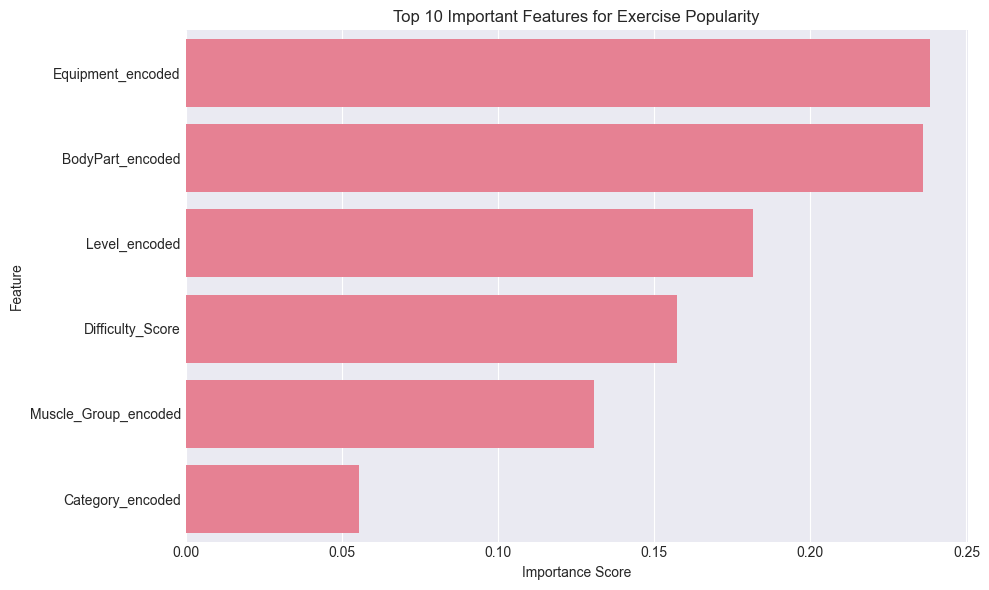

In [13]:
# Optional: Visualization of model performance
if 'feature_importance' in locals():
    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(10)
    sns.barplot(x='importance', y='feature', data=top_features)
    plt.title('Top 10 Important Features for Exercise Popularity')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


In [14]:
# Save the notebook summary
summary = {
    "training_date": datetime.now().isoformat(),
    "dataset_size": len(df_clean),
    "models_trained": ["Popularity Prediction", "Difficulty Classification"],
    "exported_files": ["trained_workout_data.json", "exercise_lookup.json", "workout_rules.json"],
    "performance_metrics": {
        "popularity_rmse": float(rmse) if 'rmse' in locals() else 0,
        "difficulty_accuracy": float(accuracy) if 'accuracy' in locals() else 0
    }
}

with open('training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ Training summary saved to training_summary.json")

✅ Training summary saved to training_summary.json
